In [1]:
import functions
import os
from data import data, path_map, masks, path_masks
import healpy as hp

In [4]:
# Default configuration
nside = 512
n_sim = 100
path_save = path_map + 'PYSM/'

quijote_bands = ['11']
wmap_bands = ['23', '33', '41', '61', '94']
planck_bands = ['30', '44', '70', '100', '143', '217', '353']


band_list = quijote_bands + wmap_bands + planck_bands

name_suffix = '_full'

# Differential Assemblies (DAs) per frequency band
BANDS = {
    'K': ['K1'],
    'Ka': ['Ka1'],
    'Q': ['Q1', 'Q2'],
    'V': ['V1', 'V2'],
    'W': ['W1', 'W2', 'W3', 'W4'],
}

lmax = 2 * nside - 1
dl = 10

mask_select = masks['QUIJOTE_galcut']['galcut10_10mk']
mask_name = mask_select['name']
use_simulated_maps = False
use_white_noise = False
use_noise = False # Use noise simulations instead of the HMDM
out_path = '/home/pablo/Desktop/master/tfm/spectra/'
path_spectra = os.path.join(out_path, f'power_spectra_{mask_name}{name_suffix}.fits')
if use_noise:
    path_hmdm_spectra = os.path.join(out_path, f'power_spectra_{mask_name}_noise_sim{name_suffix}.fits')
else:
    path_hmdm_spectra = os.path.join(out_path, f'power_spectra_{mask_name}_hmdm{name_suffix}.fits')
path_avg_std_skyplusnoise = os.path.join(out_path, f'spectra_avg_std_{mask_name}_avg_std{n_sim}_skyplusnoise{name_suffix}.fits')
path_avg_std_noise = os.path.join(out_path, f'spectra_avg_std_{mask_name}_avg_std{n_sim}_noise{name_suffix}.fits')
path_corrected_spectra = os.path.join(out_path, f'corrected_power_spectra_{mask_name}{name_suffix}.fits')

mask = hp.read_map(mask_select['path'])

#Create binning scheme
ell_1 = [30, 50, 70, 90, 110, 130]
ell_2 = [49, 69, 89, 109, 129, 149]

binning_params = {
    'type': 'linear',  # or 'edges'
    'lmax': lmax,
    'dl': dl,
    # For edges
    'ell1': ell_1,
    'ell2': ell_2
}

$\textbf{Part 1: Simulated maps using PySM}$

In [3]:

# Generate maps
functions.generate_sky_maps(nside, path_save, experiment_select='QUIJOTE', band_select=quijote_bands)
functions.generate_sky_maps(nside, path_save, experiment_select='WMAP', band_select=wmap_bands)
functions.generate_sky_maps(nside, path_save, experiment_select='Planck', band_select=planck_bands)

/home/pablo/Desktop/master/tfm/python/1-methodology_tests/functions.py:228: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  return hp.alm2map([almT, almE, almB], nside=nside_map, pol=True, lmax=lmax, verbose=False)


[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map_QUIJOTE_11_nside512_beamconv.fits
[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map_WMAP_23_nside512_beamconv.fits
[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map_WMAP_33_nside512_beamconv.fits
[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map_WMAP_41_nside512_beamconv.fits
[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map_WMAP_61_nside512_beamconv.fits
[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map_WMAP_94_nside512_beamconv.fits
[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map_Planck_30_nside512_beamconv.fits
[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map_Planck_44_nside512_beamconv.fits
[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map_Planck_70_nside512_beamconv.fits
[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map_Planck_100_nside512_beamconv.fits
[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map_Planck_143_nside512_beamconv.fits
[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map_Planck_217_nside512_beamconv.fits
[OK] Saved: /media/pablo/cmb_ssd/maps/PYSM/map

$\textbf{Part 2: Simulated white noise maps}$

In [ ]:
functions.white_noise_maps(data, nside, experiment_select='QUIJOTE', band_select=quijote_bands, n_sim=n_sim, path_map=path_map)
functions.white_noise_maps(data, nside, experiment_select='WMAP', band_select=wmap_bands, n_sim=n_sim, path_map=path_map)
functions.white_noise_maps(data, nside, experiment_select='Planck', band_select=planck_bands, n_sim=n_sim, path_map=path_map)

$\textbf{Part 3: Build HMDM}$

In [ ]:

base_dir = os.path.dirname(data['WMAP']['23']['hmdm'])
save_path = os.path.dirname(data['WMAP']['23']['hmdm'])

combined_1to4 = functions.coadd_year_range(base_dir=base_dir, year_1=1, year_2=4, save=True, save_path=save_path)
combined_5to9 = functions.coadd_year_range(base_dir=base_dir, year_1=5, year_2=9, save=True, save_path=save_path)

In [ ]:
functions.make_hmdm(data, band_list, save=True)

$\textbf{Part 4: Build beams WMAP}$

In [ ]:
beam_path = os.path.dirname(data['WMAP']['23']['beam'])
save_path = os.path.dirname(data['WMAP']['23']['beam'])

functions.generate_band_beams(BANDS, beam_path=beam_path, save_path=save_path)

$\textbf{Part 5: Compute power spactra}$

In [4]:
# 1. Prepare binning scheme
b = functions.create_binning(binning_params)

In [5]:
# 2. Precompute workspaces
workspaces = functions.prepare_workspaces(mask, b, nside, lmax=lmax, purify_e=True, purify_b=True)

In [6]:
# 3. Compute all spectra
spectra_matrix = functions.compute_all_power_spectra(
    data, band_list, mask, b,
    use_simulated_maps=use_simulated_maps,
    use_white_noise=use_white_noise,
    noise_realization=1,
    only_noise=False,
    workspaces=workspaces,
    lmax=lmax
)

# 4. Save spectra matrix into a FITS file
functions.save_spectra_to_fits(spectra_matrix, band_list, out_file=path_spectra)

Saved power spectra matrix to /home/pablo/Desktop/master/tfm/spectra/power_spectra_quijote_galcut10_10mk_full.fits


In [7]:
# 5. Compute HMDM spectra
hmdm_spectra_matrix = functions.compute_hmdm_power_spectra(
    data, band_list, mask, b, workspaces=workspaces, lmax=lmax, use_noise=use_noise
)

# 6. Save spectra matrix into a FITS file
functions.save_spectra_to_fits(hmdm_spectra_matrix, band_list, out_file=path_hmdm_spectra)

Saved power spectra matrix to /home/pablo/Desktop/master/tfm/spectra/power_spectra_quijote_galcut10_10mk_hmdm_full.fits


In [8]:
# 7. Read spectra matrix from FITS
spectra_dict = functions.read_spectra_from_fits(path_spectra, band_list)

In [8]:
# 8. Compute mean and std over noise realizations (sky + noise)
avg_std_skyplusnoise_dict = functions.average_and_std_spectra(
    data, spectra_dict, band_list, mask, b,
    use_white_noise=use_white_noise,
    n_sim=n_sim, 
    only_noise=False,
    workspaces=workspaces,
    lmax=lmax
)


functions.save_avg_std_to_fits(avg_std_skyplusnoise_dict, band_list,
                     out_file=path_avg_std_skyplusnoise,
                     use_white_noise=use_white_noise
)

# 9. Compute mean and std for noise-only maps
avg_std_noise_dict = functions.average_and_std_spectra(
    data, spectra_dict, band_list, mask, b,
    use_white_noise=use_white_noise,
    n_sim=n_sim,
    only_noise=True,
    workspaces=workspaces,
    lmax=lmax
)

functions.save_avg_std_to_fits(avg_std_noise_dict, band_list,
                     out_file=path_avg_std_noise,
                     use_white_noise=use_white_noise
)


Simulations: 100%|██████████| 100/100 [17:53:20<00:00, 644.00s/it] 


Saved avg+std spectra to /home/pablo/Desktop/master/tfm/spectra/spectra_avg_std_quijote_galcut10_10mk_avg_std100_skyplusnoise_sim.fits


Simulations: 100%|██████████| 100/100 [17:11:28<00:00, 618.89s/it] 


Saved avg+std spectra to /home/pablo/Desktop/master/tfm/spectra/spectra_avg_std_quijote_galcut10_10mk_avg_std100_noise_sim.fits


$\textbf{Part 6: Correct power spectra}$

In [12]:
corr_spectra, out_file = functions.correct_power_spectra(
    path_spectra, path_avg_std_skyplusnoise, path_avg_std_noise,
    band_list, data, nside, 
    correct_beam=True, 
    correct_unit=True,
    correct_pixel=True, 
    save=True, 
    path_out_file=path_corrected_spectra,
    use_white_noise=use_white_noise, 
    path_hmdm_spectra=path_hmdm_spectra
)

[INFO] get_beam_for_band: band 11 had 51 negative beam values after interpolation; setting them to 0
[OK] Saved corrected spectra with errors to /home/pablo/Desktop/master/tfm/spectra/corrected_power_spectra_quijote_galcut10_10mk_full.fits


$\textbf{Part 7: MCMC fitting}$

In [5]:
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

'1'

In [22]:
# -------------------------------
# Fitting configuration
# -------------------------------

# Choose 'EE' or 'BB' here to select which mode to prepare and fit
fit_mode = 'EE'

# Fit ell range
ell_min = 30
ell_max = 200

nwalkers = 200
ninter = 5000
discard_fraction = 0.5

fit_components = (
    'sync', 
    'dust', 
    'cross'
)

# band_pairs = [
#     '11_11', '23_23', '30_30',
#     '11_23', '11_30', '23_30',
# ]

band_pairs = 'all'

fit_c_terms = False

# Save path of the figure
components_str = '_'.join(fit_components)
save_path = f'/home/pablo/Desktop/master/tfm/figures/1-methodology_tests/corner/corner_{components_str}_{fit_mode}{name_suffix}.pdf'

save_path = None

In [23]:
spectra_dict = functions.read_corrected_cls(path_corrected_spectra, band_list)

In [24]:
# Prepare data first
fit_data = functions.prepare_mcmc_data(
    spectra_dict,
    band_list=band_list,
    modes=[fit_mode],
    ell_min=ell_min,
    ell_max=ell_max,
    band_pairs=band_pairs
)

# Run MCMC
sampler, samples_full, samples_free, param_map, chi2_reduced = functions.run_mcmc(
    fit_data=fit_data,
    fit_components=fit_components,
    fit_c_terms=fit_c_terms,
    nwalkers=nwalkers,
    ninter=ninter,
    discard_fraction=discard_fraction
)

[run_mcmc] Using 20 processes (of 20) with 200 walkers
[run_mcmc] Starting MCMC...


100%|██████████| 5000/5000 [10:07<00:00,  8.23it/s]

[run_mcmc] MCMC completed. 500000 usable samples after burn-in.
[run_mcmc] Reduced chi-squared at best fit: 3.8843


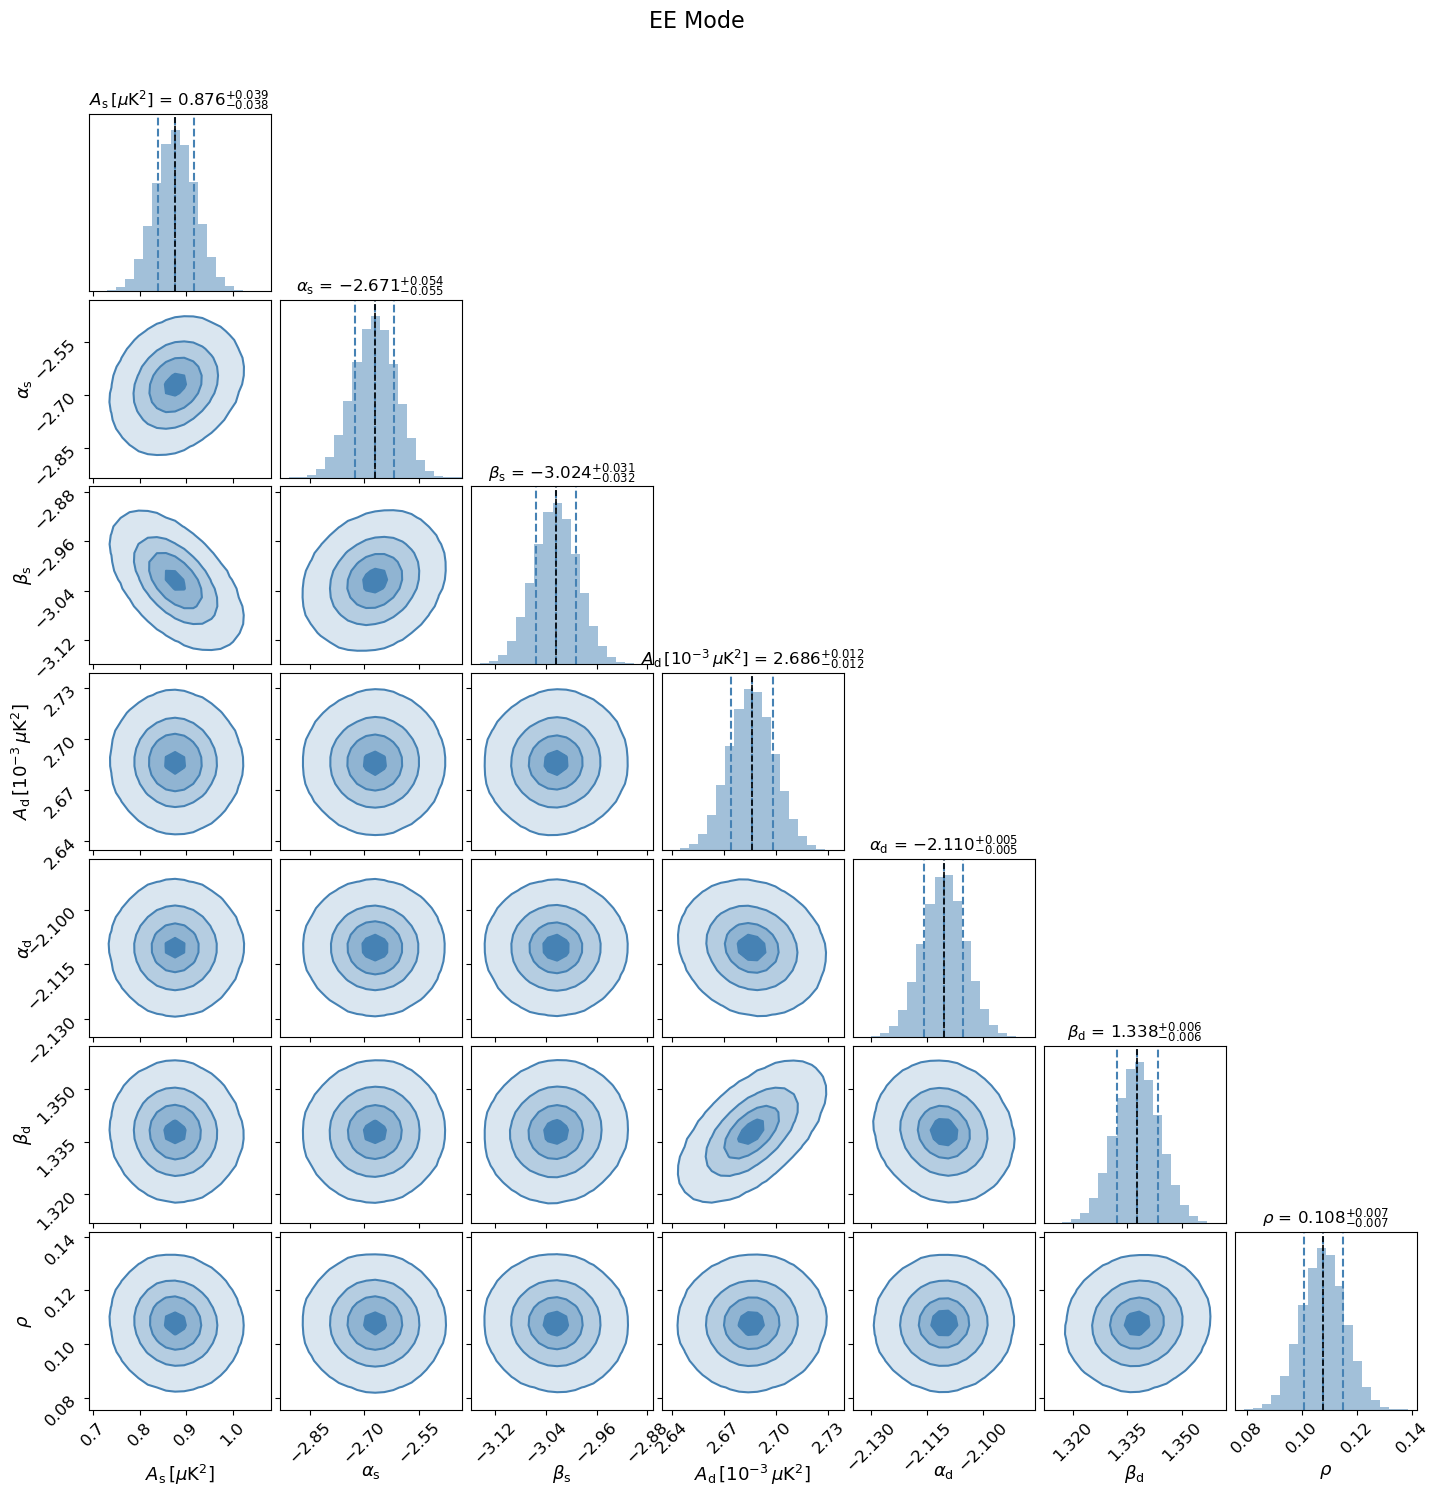

In [25]:
# Plot and save the corner plot
fig = functions.plot_corner(samples_free, param_map, save_path, title=f'{fit_mode} Mode')

In [26]:
chi2_reduced

3.8842727751578634

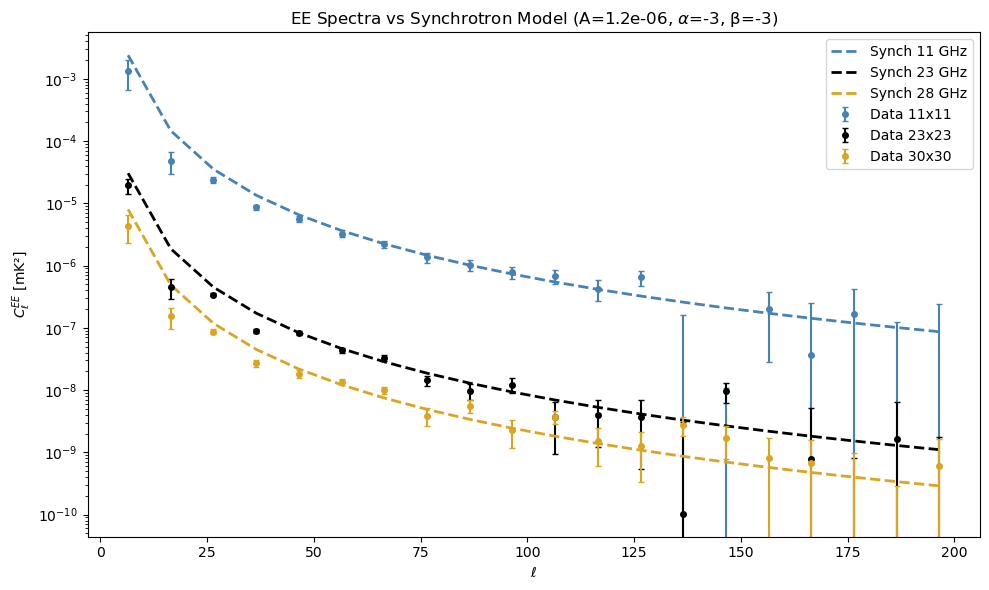

In [52]:
import matplotlib.pyplot as plt

theta_synch = [1.2e-6, -3, -3]

# theta_synch = [1.2e-6, -2.28, -2.8]

bands = ['11_11', '23_23', '30_30']
colors = ['steelblue', 'k', 'goldenrod']

freq_11 = data['QUIJOTE']['11']['freq'].to('GHz').value
freq_23 = data['WMAP']['23']['freq'].to('GHz').value
freq_30 = data['Planck']['30']['freq'].to('GHz').value
frequencies = [freq_11, freq_23, freq_30]

datasets = []
for freq in frequencies:
    datasets.append({'freqs': [freq, freq]})  # Auto-espectros

first_band = bands[0]
if first_band in corr_spectra:
    ell_eff = corr_spectra[first_band]['ell_eff']
    mask = (ell_eff >= 0) & (ell_eff <= 200)
    ell_plot = ell_eff[mask]
    
    model_spectra = functions.model_synchrotron(
        theta_synch, datasets, ell_plot, 
        fit_c_terms=False, freq_ref=11.1, ell_ref=80.0
    )
    
    n_ell = len(ell_plot)
    model_bands = [model_spectra[i*n_ell:(i+1)*n_ell] for i in range(len(bands))]
    
    # Crear el plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i, (band, color, model_spec) in enumerate(zip(bands, colors, model_bands)):
        if band in corr_spectra and 'EE' in corr_spectra[band]:
            spectrum = corr_spectra[band]['EE']['SPECTRUM'][mask]
            error = corr_spectra[band]['EE']['ERROR'][mask]
            
            ax.errorbar(ell_plot, spectrum, yerr=error, 
                       fmt='o', color=color, markersize=4, capsize=2,
                       label=f'Data {band.replace("_", "x")}')
            
            ax.plot(ell_plot, model_spec, '--', color=color, linewidth=2,
                   label=f'Synch {frequencies[i]:.0f} GHz')
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$C_\ell^{EE}$ [mK²]')
    ax.set_yscale('log')
    ax.legend()
    ax.set_title(rf'EE Spectra vs Synchrotron Model (A={theta_synch[0]}, $\alpha$={theta_synch[1]}, β={theta_synch[2]})')
    plt.tight_layout()
    plt.show()